# Random Forest: re-evaluation

Re-run of `random_forest.ipynb` on the surviving data.

**Same as the original:** displacement-vector windows (25 steps × 25 keypoints × (Δx, Δy)), flattened to 1,250 features; `RandomForestClassifier(max_depth=15, n_estimators=150)` with no hyperparameter search.

**Different from the original:** the original put the first 20% of each class's recording files into a single test set, on a dataset that no longer exists. Here the model is scored with the shared protocol below.

**Evaluation protocol (shared by every `reeval_*` notebook, see `src/reeval_common.py`):**

- Data: `data/keypoint_sequences.csv`, 41 Kinect recordings that survived; the larger folder the thesis notebooks used is lost.
- 6 classes, as in the thesis models: `squat_front` and `squat_side` are merged into `squat`.
- Stratified 5-fold cross-validation over **recordings**, repeated with 3 shuffles (15 splits). All windows of a recording are on the same side of every split.
- Nothing from a test fold is used for training, hyperparameter search or early stopping.
- Reported per split: window accuracy, macro F1, accuracy after a majority vote per recording (what the real-time system does), and a majority-class baseline.
- The spread across splits is shown as ± one standard deviation. Splits share recordings, so this understates the true uncertainty; with 41 recordings, differences of a few points are not meaningful.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "keypoint_sequences.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import reeval_common as rc

records = rc.load_recordings()
table = rc.recordings_table(records)
table.groupby("label").agg(recordings=("rec_id", "count"), frames=("n_frames", "sum"))

,recordings,frames
label,,
bent-over_rows,6,456
biceps,6,456
latheral_raises,6,455
rdl,6,455
shoulder_press,6,456
squat,11,836


In [2]:
X, y, groups = rc.displacement_windows(records)
print("windows:", X.shape, "(windows, steps, keypoints, dx/dy)")
pd.Series(y).value_counts().rename("windows").to_frame()

windows: (121, 25, 25, 2) (windows, steps, keypoints, dx/dy)


,windows
squat,33
bent-over_rows,18
biceps,18
shoulder_press,18
latheral_raises,17
rdl,17


In [3]:
from sklearn.ensemble import RandomForestClassifier


def fit_predict(X_train, y_train, groups_train, X_test, seed):
    clf = RandomForestClassifier(max_depth=15, n_estimators=150, random_state=seed, n_jobs=-1)
    clf.fit(X_train.reshape(len(X_train), -1), y_train)
    return clf.predict(X_test.reshape(len(X_test), -1))


result = rc.evaluate(
    fit_predict, X, y, groups, rc.recording_splits(groups, records),
    model="Random Forest", variant="windows", split="recording-level 5-fold × 3",
    features="displacement windows, flattened (1,250)", params="max_depth=15, n_estimators=150",
)
rc.save_results(result, "random_forest")
rc.summary_table([result])

,model,variant,split,samples,splits run,accuracy,macro F1,recording vote,majority baseline
0,Random Forest,windows,recording-level 5-fold × 3,121,15,61.2% ± 7.9%,55.8% ± 9.2%,66.9% ± 14.5%,27.1%


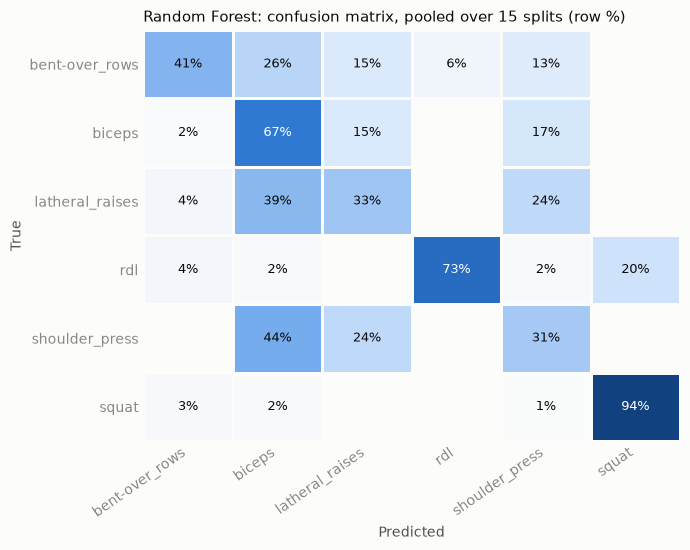

In [4]:
rc.plot_confusion(result, "Random Forest: confusion matrix, pooled over 15 splits (row %)", "random_forest_confusion.png");